<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/flowassurance/hydrate_wax_and_water_margin_screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hydrate, Wax, and Water Margin Screening

Screen operating margin against hydrate temperature, wax appearance temperature, and water dew point assumptions before doing a detailed flow-assurance study.


## Setup

This educational screening combines NeqSim properties with transparent public assumptions.


In [1]:
# Install NeqSim when running in a fresh Colab session.
try:
    import neqsim
except ImportError:
    %pip install neqsim

import json
import pandas as pd
import matplotlib.pyplot as plt
from neqsim import jneqsim
from neqsim.thermo import TPflash

SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

def make_gas(temperature_c=25.0, pressure_bara=60.0):
    fluid = SystemSrkEos(273.15 + temperature_c, pressure_bara)
    fluid.addComponent("nitrogen", 0.01)
    fluid.addComponent("CO2", 0.02)
    fluid.addComponent("methane", 0.86)
    fluid.addComponent("ethane", 0.07)
    fluid.addComponent("propane", 0.03)
    fluid.addComponent("n-butane", 0.01)
    fluid.setMixingRule("classic")
    TPflash(fluid)
    fluid.initProperties()
    return fluid


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 31.7 MB/s eta 0:00:00


## Define Operating Cases

Use a simple table of pipeline operating points.


In [2]:
cases = pd.DataFrame({
    "case": ["warm export", "normal export", "cold restart"],
    "pressure_bara": [80.0, 70.0, 60.0],
    "temperature_C": [35.0, 18.0, 6.0],
})
cases


,case,pressure_bara,temperature_C
0,warm export,80.0,35.0
1,normal export,70.0,18.0
2,cold restart,60.0,6.0


## Screen Margins

The placeholder equilibrium temperatures are deliberately conservative and should be replaced by validated NeqSim hydrate/wax methods in detailed work.


In [3]:
rows = []
for _, case in cases.iterrows():
    fluid = make_gas(float(case.temperature_C), float(case.pressure_bara))
    hydrate_equilibrium_C = 12.0 + 0.03 * case.pressure_bara
    wax_appearance_C = 8.0
    water_dew_point_C = -5.0 + 0.02 * case.pressure_bara
    rows.append({
        "case": case.case,
        "operating_temperature_C": case.temperature_C,
        "hydrate_margin_C": case.temperature_C - hydrate_equilibrium_C,
        "wax_margin_C": case.temperature_C - wax_appearance_C,
        "water_dew_point_margin_C": case.temperature_C - water_dew_point_C,
        "gas_density_kg_per_m3": fluid.getDensity("kg/m3"),
    })
margin = pd.DataFrame(rows)
margin


,case,operating_temperature_C,hydrate_margin_C,wax_margin_C,water_dew_point_margin_C,gas_density_kg_per_m3
0,warm export,35.0,20.6,27.0,38.4,69.654578
1,normal export,18.0,3.9,10.0,21.6,66.215282
2,cold restart,6.0,-7.8,-2.0,9.8,59.684645


## Visualize Margins

Negative margin flags cases that need detailed checks.


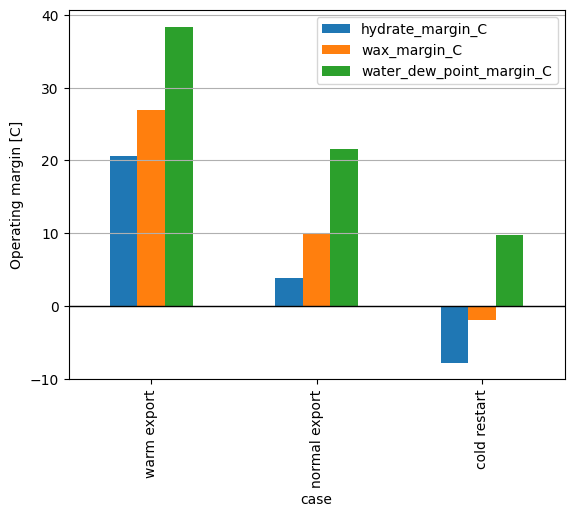

In [4]:
ax = margin.set_index("case")[["hydrate_margin_C", "wax_margin_C", "water_dew_point_margin_C"]].plot(kind="bar")
ax.axhline(0.0, color="black", linewidth=1)
ax.set_ylabel("Operating margin [C]")
ax.grid(True, axis="y")
plt.show()
